# Caracterización de la tirada en FATE2d6

Este notebook analiza matemáticamente la tirada base del sistema:

**2d6 + Atributo + Habilidad**

El objetivo es caracterizar cómo se comporta la tirada en términos de
probabilidad y dificultad, tomando como punto de partida una configuración
concreta del sistema definida en un archivo JSON.

## Objetivos del análisis

- Analizar la distribución de frecuencias del modificador `Atributo + Habilidad`.
- Calcular el valor esperado del modificador a la tirada (E[m]).
- Estudiar la distribución de probabilidad de distintas tiradas posibles.
- Comparar el comportamiento de la tirada frente a la escala de dificultades del sistema.
- Dejar una base reutilizable para analizar otras configuraciones del juego.

## Setup

En esta sección se prepara el entorno de trabajo del notebook:

- se resuelven las rutas del proyecto
- se importan las dependencias necesarias
- se carga la configuración del sistema desde un archivo JSON

Para reutilizar este notebook con otra variante del sistema, basta con cambiar
la ruta del archivo de configuración en la celda siguiente.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

ROOT = Path().resolve().parent
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from fate2d6.config import load_config
from fate2d6.probability import *

CONFIG_PATH = ROOT / "config" / "base.json"
config = load_config(CONFIG_PATH)

print("LOAD OK")
print(f"Sistema cargado: {config.system_name}")
print(f"Configuración usada: {CONFIG_PATH}")

LOAD OK
Sistema cargado: FATE2d6 Base
Configuración usada: /home/darofar/rol/fate2d6/config/base.json


## Análisis de la Configuración

La configuración cargada define el conjunto de atributos, habilidades y valores
asociados que se usarán para calcular el espacio de modificadores posibles del
sistema.

Al cambiar el archivo JSON de configuración, este notebook puede reutilizarse
para analizar otras variantes de FATE2d6.

In [2]:
print("Configuración:", config.system_name)
print("Atributos:", config.attribute_names)
print("Distribución de atributos:", config.attribute_value_distribution)
print("Habilidades:", config.skill_names)
print("Distribución de habilidades:", config.skill_value_distribution)

Configuración: FATE2d6 Base
Atributos: ['Agilidad', 'Carisma', 'Fisico', 'Intelecto', 'Sabiduria']
Distribución de atributos: [-1, 0, 1, 1, 2]
Habilidades: ['Atletismo', 'Conducir', 'Conocimientos[]', 'Contactos', 'Disparar', 'Empatia', 'Engañar', 'Investigar', 'Luchar', 'Notar', 'Oficio[]', 'Persuadir', 'Poder', 'Protocolo', 'Provocar', 'Recursos', 'Sigilo', 'Técnica']
Distribución de habilidades: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2]


## Distribución del modificador `Atributo + Habilidad`

A continuación se calculan todas las combinaciones posibles entre los valores
de atributos y los valores de habilidades definidos en la configuración
cargada.

El objetivo de esta parte es obtener:

- la frecuencia de cada modificador posible
- la probabilidad asociada a cada uno
- el valor esperado del modificador

Esta distribución describe la estructura interna del sistema para la
configuración elegida. No representa todavía el uso real en mesa, ya que la
frecuencia efectiva de cada combinación dependerá también de la ficción y de
las decisiones de los jugadores.

Configuración: FATE2d6 Base
Total de combinaciones: 90
Valor esperado del modificador: 1.7111
Moda: 2
Desviación típica: 1.2583


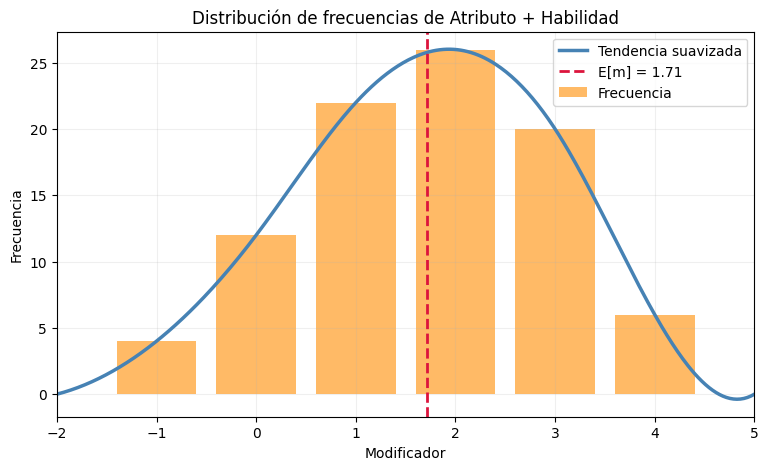

,Modificador,Frecuencia,Probabilidad,Porcentaje
0,-1,4,0.044,4.4%
1,0,12,0.133,13.3%
2,1,22,0.244,24.4%
3,2,26,0.289,28.9%
4,3,20,0.222,22.2%
5,4,6,0.067,6.7%


In [3]:
distribution = modifier_distribution(config)
probabilities = modifier_probabilities(config)
total = total_modifier_combinations(config)
expected = expected_modifier(config)
mode = modifier_mode(config)
std = modifier_std(config)

rows = []
for modifier, frequency in distribution.items():
    rows.append(
        {
            "Modificador": modifier,
            "Frecuencia": frequency,
            "Probabilidad": probabilities[modifier],
            "Porcentaje": probabilities[modifier] * 100,
        }
    )

df_modifiers = pd.DataFrame(rows)

df_modifiers_display = df_modifiers.copy()
df_modifiers_display["Probabilidad"] = df_modifiers_display["Probabilidad"].map(
    lambda x: f"{x:.3f}"
)
df_modifiers_display["Porcentaje"] = df_modifiers_display["Porcentaje"].map(
    lambda x: f"{x:.1f}%"
)

print("Configuración:", config.system_name)
print("Total de combinaciones:", total)
print("Valor esperado del modificador:", round(expected, 4))
print("Moda:", mode)
print("Desviación típica:", round(std, 4))

x = np.array([-2, -1, 0, 1, 2, 3, 4, 5])
y = np.array([0, 4, 12, 22, 26, 20, 6, 0])

x_smooth = np.linspace(-2, 5, 400)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

plt.figure(figsize=(9, 5))

plt.bar(
    df_modifiers["Modificador"].values,
    df_modifiers["Frecuencia"].values,
    alpha=0.6,
    color="darkorange",
    label="Frecuencia",
)

plt.plot(
    x_smooth,
    y_smooth,
    color="steelblue",
    linewidth=2.5,
    label="Tendencia suavizada",
)

plt.axvline(
    expected,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"E[m] = {expected:.2f}",
)

plt.title("Distribución de frecuencias de Atributo + Habilidad")
plt.xlabel("Modificador")
plt.ylabel("Frecuencia")
plt.xticks(np.arange(-2, 6, 1))
plt.xlim(-2, 5)
plt.legend()
plt.grid(alpha=0.2)

plt.show()

df_modifiers_display

### Interpretación de la distribución de modificadores

La tabla y la gráfica anteriores muestran cómo se distribuyen los valores de
`Atributo + Habilidad` en función de la configuración cargada.

Esta distribución refleja:

- qué modificadores son más frecuentes dentro del sistema
- qué valores extremos aparecen con menor probabilidad
- dónde se sitúa el centro de gravedad del sistema (valor esperado)

En general, esta forma describe la estructura matemática del sistema para la
configuración seleccionada. No representa directamente el uso real en partida,
ya que:

- no todas las combinaciones atributo-habilidad son igualmente naturales
- la ficción restringe ciertas acciones
- los jugadores tenderán a optimizar sus elecciones

Por tanto, esta distribución debe interpretarse como una **base estructural**
sobre la que luego se superpone el comportamiento real en mesa.

---

### Caso particular: configuración base

Si se utiliza la configuración base del sistema, definida en `base.json`, los
valores observados son:

- `-1`: 4 casos  
- `0`: 12 casos  
- `1`: 22 casos  
- `2`: 26 casos  
- `3`: 20 casos  
- `4`: 6 casos  

Esto muestra una clara concentración en torno a los valores positivos,
especialmente `+2`, que es el modificador más frecuente.

El valor esperado del modificador es aproximadamente **1.71**, lo que indica que
el sistema, en términos estructurales, está desplazado hacia valores positivos.

Si se modifica la configuración JSON, esta distribución cambiará y deberá
interpretarse de nuevo siguiendo este mismo esquema.

## Baseline estructural: `2d6 + E[m]`

Dado que la distribución de `2d6` es bien conocida en juegos de rol, el interés
del análisis no está en la tirada base aislada, sino en cómo se comporta al
combinarse con los modificadores del sistema.

Como primera aproximación se toma el valor esperado del modificador
`Atributo + Habilidad`, denotado por `E[m]`, y se desplaza la tirada `2d6` por
ese valor.

Este baseline no pretende representar exactamente el uso real en mesa, pero sí
ofrece una referencia estructural útil y conservadora para estudiar la relación
entre la tirada y la escala de dificultades del sistema.

Baseline estructural: 2d6 + E[m]
E[m]: 1.7111
Valor esperado de la tirada baseline: 8.7111


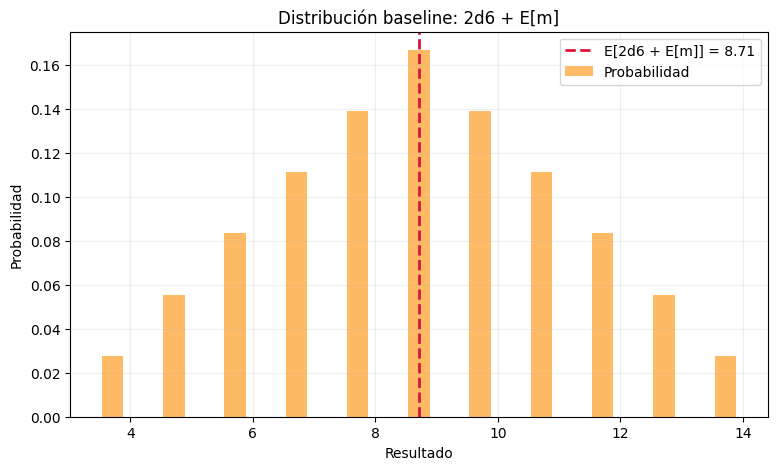

,Resultado,Probabilidad,Porcentaje
0,3.71,0.028,2.8%
1,4.71,0.056,5.6%
2,5.71,0.083,8.3%
3,6.71,0.111,11.1%
4,7.71,0.139,13.9%
5,8.71,0.167,16.7%
6,9.71,0.139,13.9%
7,10.71,0.111,11.1%
8,11.71,0.083,8.3%
9,12.71,0.056,5.6%


In [4]:
baseline_distribution = shifted_two_d6_distribution(expected)

rows_baseline = []
for result, probability in sorted(baseline_distribution.items()):
    rows_baseline.append(
        {
            "Resultado": result,
            "Probabilidad": probability,
            "Porcentaje": probability * 100,
        }
    )

df_baseline = pd.DataFrame(rows_baseline)

df_baseline_display = df_baseline.copy()
df_baseline_display["Resultado"] = df_baseline_display["Resultado"].map(lambda x: f"{x:.2f}")
df_baseline_display["Probabilidad"] = df_baseline_display["Probabilidad"].map(lambda x: f"{x:.3f}")
df_baseline_display["Porcentaje"] = df_baseline_display["Porcentaje"].map(lambda x: f"{x:.1f}%")

print("Baseline estructural: 2d6 + E[m]")
print("E[m]:", round(expected, 4))
print("Valor esperado de la tirada baseline:", round(7 + expected, 4))

x_baseline = df_baseline["Resultado"].values
y_baseline = df_baseline["Probabilidad"].values

x_plot = np.concatenate(([x_baseline.min() - 1], x_baseline, [x_baseline.max() + 1]))
y_plot = np.concatenate(([0], y_baseline, [0]))

x_smooth = np.linspace(x_plot.min(), x_plot.max(), 500)
spline = make_interp_spline(x_plot, y_plot, k=3)
y_smooth = spline(x_smooth)

baseline_expected = 7 + expected

plt.figure(figsize=(9, 5))

plt.bar(
    x_baseline,
    y_baseline,
    width=0.35,
    alpha=0.6,
    color="darkorange",
    label="Probabilidad",
)

# plt.plot(
#     x_smooth,
#     y_smooth,
#     color="steelblue",
#     linewidth=2.5,
#     label="Tendencia suavizada",
# )

plt.axvline(
    baseline_expected,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"E[2d6 + E[m]] = {baseline_expected:.2f}",
)

plt.title("Distribución baseline: 2d6 + E[m]")
plt.xlabel("Resultado")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

df_baseline_display

### Interpretación del baseline `2d6 + E[m]`

Una forma útil de aproximar el comportamiento global del sistema es combinar la
distribución base de `2d6` con un único modificador representativo. En este
caso, se utiliza el valor esperado del modificador `Atributo + Habilidad`,
denotado como `E[m]`.

Este enfoque permite construir un **baseline estructural** de la tirada, que
sirve como referencia para entender dónde se sitúa el centro de la distribución
y cómo se relaciona con la escala de dificultades del sistema. No pretende
describir con exactitud el comportamiento en partida, sino ofrecer una
aproximación conservadora y homogénea sobre la que comparar otros escenarios.

---

### Caso particular: baseline con `E[m]`

Para la configuración base, el valor esperado del modificador es aproximadamente
`1.71`. Al desplazar la distribución de `2d6` por este valor, el centro de la
tirada pasa de `7` a aproximadamente `8.71`.

Esto sitúa el baseline estructural del sistema muy cerca de la dificultad `9`,
que en la escala del juego corresponde al nivel **Bueno / Media**.

Esta proximidad sugiere que, incluso bajo una lectura conservadora, la tirada
tiende a concentrarse en torno a los niveles medios de dificultad del sistema.

Como en el caso anterior, esta interpretación depende de la configuración
utilizada. Si se modifica el JSON de entrada, tanto el valor esperado como la
posición del baseline cambiarán, y deberán analizarse de nuevo en su contexto.

## Distribuciones por modificador fijo

Además del baseline estructural `2d6 + E[m]`, resulta útil estudiar cómo se
comporta la tirada cuando se utiliza un modificador fijo concreto.

Este análisis permite observar de forma más precisa el efecto de cada nivel de
competencia sobre la distribución final de resultados. En particular, permite
comparar entre sí las tiradas:

- `2d6 - 1`
- `2d6 + 0`
- `2d6 + 1`
- `2d6 + 2`
- `2d6 + 3`
- `2d6 + 4`

Estas distribuciones son especialmente útiles para interpretar qué significa en
mesa tirar con un modificador concreto y cómo se desplaza la tirada respecto de
la escala de dificultades del sistema.

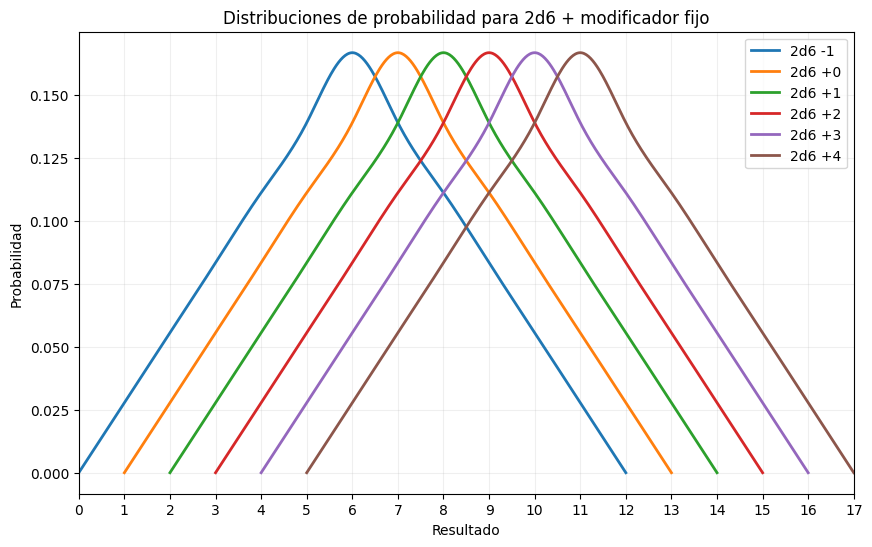

,Modificador,Valor esperado,Moda
0,-1,6.0,6
1,+0,7.0,7
2,+1,8.0,8
3,+2,9.0,9
4,+3,10.0,10
5,+4,11.0,11


In [5]:
fixed_modifiers = [-1, 0, 1, 2, 3, 4]

summary_rows = []

plt.figure(figsize=(10, 6))

for modifier in fixed_modifiers:
    shifted_distribution = shifted_two_d6_distribution(modifier)

    x = np.array([1 + modifier, *shifted_distribution.keys(), 13 + modifier])
    y = np.array([0, *shifted_distribution.values(), 0])

    x_smooth = np.linspace(x.min(), x.max(), 500)
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_smooth)

    plt.plot(
        x_smooth,
        y_smooth,
        linewidth=2,
        label=f"2d6 {modifier:+d}",
    )

    summary_rows.append(
        {
            "Modificador": f"{modifier:+d}",
            "Valor esperado": round(expected_shifted_two_d6(modifier), 3),
            "Moda": 7 + modifier,
        }
    )

plt.title("Distribuciones de probabilidad para 2d6 + modificador fijo")
plt.xlabel("Resultado")
plt.ylabel("Probabilidad")
plt.xticks(np.arange(0, 18, 1))
plt.xlim(0, 17)
plt.legend()
plt.grid(alpha=0.2)

plt.show()

df_fixed_modifiers = pd.DataFrame(summary_rows)
df_fixed_modifiers

## Interpretación de las distribuciones por modificador fijo

Las curvas anteriores muestran cómo se desplaza la distribución de `2d6` cuando
se añade un modificador fijo.

De forma general, cada incremento de `+1`:

- desplaza la distribución una unidad hacia la derecha
- aumenta el valor esperado de la tirada en una unidad
- hace más accesibles las dificultades altas
- reduce la probabilidad relativa de quedarse en resultados bajos

Esto permite interpretar de forma muy directa el impacto práctico de cada
modificador sobre la tirada.

---

### Lectura del caso concreto

En este sistema, los modificadores posibles van de `-1` a `+4`. Esto significa
que el centro de la tirada puede desplazarse desde `6` hasta `11`:

- con `-1`, la tirada orbita en torno a `6`
- con `+0`, orbita en torno a `7`
- con `+1`, orbita en torno a `8`
- con `+2`, orbita en torno a `9`
- con `+3`, orbita en torno a `10`
- con `+4`, orbita en torno a `11`

Esto ya permite anticipar una conclusión importante: los modificadores `+2` y
superiores sitúan el centro de la tirada directamente sobre la zona media-alta
de la escala de dificultades del sistema.

## Probabilidad de alcanzar o superar una dificultad

Una vez obtenidas las distribuciones por modificador fijo, el siguiente paso es
calcular la probabilidad de alcanzar o superar cada nivel de dificultad del
sistema.

Este análisis permite traducir la forma abstracta de las distribuciones a una
lectura directamente útil en mesa: qué posibilidades reales tiene un personaje,
con un modificador dado, de superar una tirada objetivo concreta.

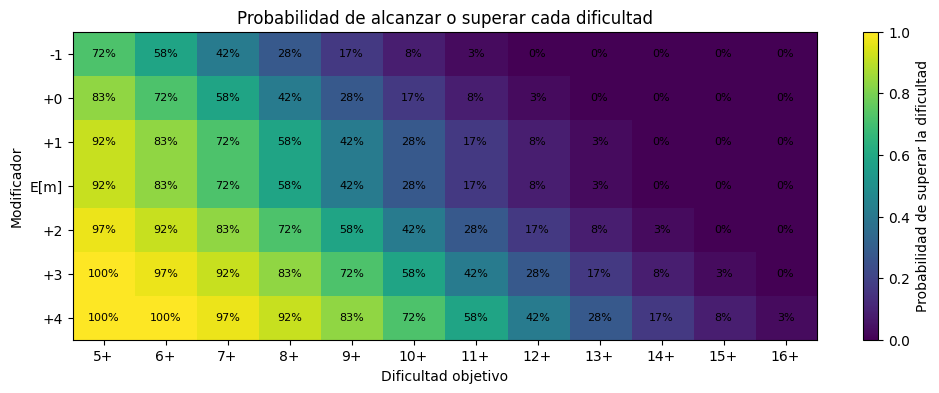

In [8]:
difficulty_thresholds = list(range(5, 17))
modifier_values = [-1, 0, 1, 2, 3, 4]

difficulty_rows = []

# Modificadores enteros
for modifier in modifier_values:
    distribution = shifted_two_d6_distribution(modifier)

    row = {
        "Modificador": modifier,
        "Label": f"{modifier:+d}",
    }

    for difficulty in difficulty_thresholds:
        row[f"{difficulty}+"] = probability_at_least(distribution, difficulty)

    difficulty_rows.append(row)

# Baseline E[m]
baseline_distribution = shifted_two_d6_distribution(expected)

baseline_row = {
    "Modificador": expected,
    "Label": "E[m]",
}

for difficulty in difficulty_thresholds:
    baseline_row[f"{difficulty}+"] = probability_at_least(
        baseline_distribution,
        difficulty,
    )

difficulty_rows.append(baseline_row)

# DataFrame y ordenación
df_difficulties = pd.DataFrame(difficulty_rows)
df_difficulties = df_difficulties.sort_values("Modificador").reset_index(drop=True)

# Preparar heatmap
heatmap_df = df_difficulties.set_index("Label").copy()

for column in heatmap_df.columns:
    if column != "Modificador":
        heatmap_df[column] = heatmap_df[column].astype(float)

heatmap_df = heatmap_df.drop(columns=["Modificador"], errors="ignore")

# Plot
plt.figure(figsize=(12, 4))
plt.imshow(heatmap_df.values, aspect="auto")

plt.colorbar(label="Probabilidad de superar la dificultad")

plt.xticks(
    ticks=np.arange(len(heatmap_df.columns)),
    labels=heatmap_df.columns,
)

plt.yticks(
    ticks=np.arange(len(heatmap_df.index)),
    labels=heatmap_df.index,
)

# Valores dentro de las celdas
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value * 100:.0f}%",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.title("Probabilidad de alcanzar o superar cada dificultad")
plt.xlabel("Dificultad objetivo")
plt.ylabel("Modificador")

plt.show()

### Interpretación de la tabla de dificultades

La tabla anterior muestra, para cada modificador, la probabilidad de alcanzar o
superar cada dificultad objetivo.

Esta representación permite leer el sistema de forma directamente operativa:

- qué dificultades son rutinarias para cada modificador
- a partir de qué punto una dificultad pasa a ser incierta
- en qué zona de la escala empieza a sentirse la presión real de la tirada

La fila `E[m]` actúa aquí como baseline estructural y permite comparar el
comportamiento agregado del sistema con los casos concretos de modificador fijo.

## Uso de Puntos Fate

En FATE2d6, los Puntos Fate representan un recurso limitado que permite a los
personajes influir directamente sobre el resultado de una tirada.

En el sistema, un Punto Fate puede emplearse de dos formas distintas:

- **Sumar un +2** al resultado de la tirada.
- **Repetir la tirada (reroll)**, sustituyendo completamente el resultado anterior.

Estas dos opciones no son equivalentes desde el punto de vista probabilístico:
una modifica el resultado existente, mientras que la otra genera uno nuevo.

En las siguientes secciones se analizará cada una de estas opciones por separado:

1. **Uso como +2**, estudiando cómo se desplaza la probabilidad de alcanzar cada dificultad.
2. **Uso como reroll**, analizando el comportamiento de una nueva tirada independiente.

Este enfoque permite aislar el efecto de cada mecánica antes de compararlas en
la interpretación de resultados.

### Uso de un Punto Fate como `+2`

Una de las formas de emplear un Punto Fate en FATE2d6 es obtener un
modificador adicional de `+2` sobre la tirada.

En esta sección se analiza cómo cambia la probabilidad de alcanzar o superar
cada dificultad cuando se añade ese bono a la tirada base.

El objetivo es comparar, para cada modificador posible del sistema, el efecto
de desplazar la distribución dos unidades hacia la derecha.

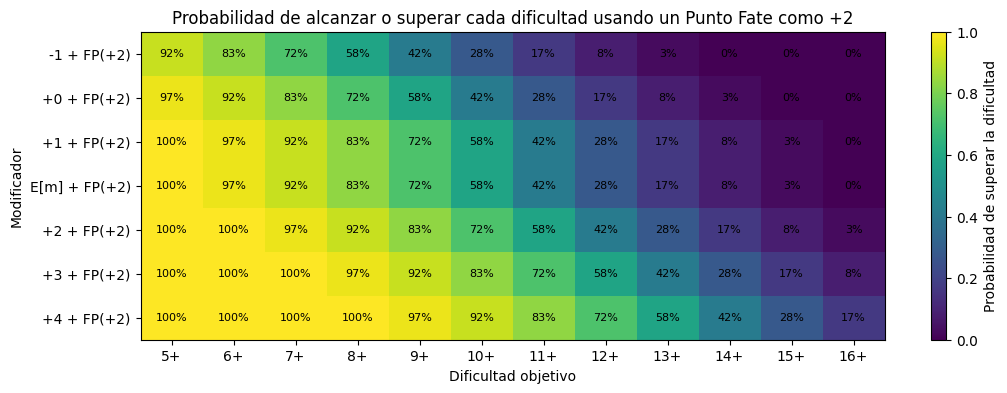

In [9]:
difficulty_thresholds = list(range(5, 17))
modifier_values = [-1, 0, 1, 2, 3, 4]

difficulty_rows_fp_plus2 = []

# Modificadores enteros con Punto Fate como +2
for modifier in modifier_values:
    boosted_modifier = modifier + 2
    distribution = shifted_two_d6_distribution(boosted_modifier)

    row = {
        "Modificador": boosted_modifier,
        "Label": f"{modifier:+d} + FP(+2)",
    }

    for difficulty in difficulty_thresholds:
        row[f"{difficulty}+"] = probability_at_least(distribution, difficulty)

    difficulty_rows_fp_plus2.append(row)

# Baseline E[m] con Punto Fate como +2
baseline_distribution_fp_plus2 = shifted_two_d6_distribution(expected + 2)

baseline_row_fp_plus2 = {
    "Modificador": expected + 2,
    "Label": "E[m] + FP(+2)",
}

for difficulty in difficulty_thresholds:
    baseline_row_fp_plus2[f"{difficulty}+"] = probability_at_least(
        baseline_distribution_fp_plus2,
        difficulty,
    )

difficulty_rows_fp_plus2.append(baseline_row_fp_plus2)

# DataFrame y ordenación
df_difficulties_fp_plus2 = pd.DataFrame(difficulty_rows_fp_plus2)
df_difficulties_fp_plus2 = (
    df_difficulties_fp_plus2
    .sort_values("Modificador")
    .reset_index(drop=True)
)

# Preparar heatmap
heatmap_fp_plus2 = df_difficulties_fp_plus2.set_index("Label").copy()

for column in heatmap_fp_plus2.columns:
    if column != "Modificador":
        heatmap_fp_plus2[column] = heatmap_fp_plus2[column].astype(float)

heatmap_fp_plus2 = heatmap_fp_plus2.drop(columns=["Modificador"], errors="ignore")

# Plot
plt.figure(figsize=(12, 4))
plt.imshow(heatmap_fp_plus2.values, aspect="auto")

plt.colorbar(label="Probabilidad de superar la dificultad")

plt.xticks(
    ticks=np.arange(len(heatmap_fp_plus2.columns)),
    labels=heatmap_fp_plus2.columns,
)

plt.yticks(
    ticks=np.arange(len(heatmap_fp_plus2.index)),
    labels=heatmap_fp_plus2.index,
)

for i in range(heatmap_fp_plus2.shape[0]):
    for j in range(heatmap_fp_plus2.shape[1]):
        value = heatmap_fp_plus2.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value * 100:.0f}%",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.title("Probabilidad de alcanzar o superar cada dificultad usando un Punto Fate como +2")
plt.xlabel("Dificultad objetivo")
plt.ylabel("Modificador")

plt.show()

### Uso de un Punto Fate como reroll

Otra forma de emplear un Punto Fate es repetir completamente la tirada,
sustituyendo el resultado anterior por uno nuevo.

Para analizar este caso, se considera que:

- se realiza una primera tirada normal
- si esta no tiene éxito, se realiza una segunda tirada independiente

La probabilidad total de éxito viene dada por:

- la probabilidad de éxito en la primera tirada
- más la probabilidad de fallar la primera y tener éxito en la segunda

Este enfoque permite modelar el reroll como un incremento de la probabilidad de
éxito, sin necesidad de introducir estrategias de decisión sobre cuándo utilizarlo.